# 🪖 Helmet Violation Detection — Training Notebook

Use dataset from Roboflow, Train YOLOv8, Results & metrics and Download `best.pt`


---
## Cell 1 — Packages

In [ ]:
!pip install ultralytics roboflow -q

import ultralytics
print(f'ultralytics version: {ultralytics.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 44.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics version: 8.4.23


---
## Cell 2 — Check GPU

In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f' GPU: {gpu_name}')
    print(f'   VRAM: {gpu_mem:.1f} GB')
else:
    print('  No found GPU!')

✅ GPU: Tesla T4
   VRAM: 15.6 GB


---
## Cell 3 — Mount Google Drive

Save checkpoints to Drive so they **are not lost when Colab shuts down.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

SAVE_DIR = '/content/drive/MyDrive/helmet_detection'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f' Drive mounted. The results will be saved at: {SAVE_DIR}')

Mounted at /content/drive
✅ Drive mounted. Kết quả sẽ lưu tại: /content/drive/MyDrive/helmet_detection


---
## Cell 4 — Downloading the dataset from Roboflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="api_key_here")
project = rf.workspace("cv-wln9e").project("helmet_detection-2v3pg")
version = project.version(1)
dataset = version.download("YOLO26")
# ─────────────────────────────────────────────────────────────────────────

DATA_YAML = f'{dataset.location}/data.yaml'
print(f' Dataset downloaded here: {dataset.location}')
print(f'   data.yaml: {DATA_YAML}')

# Quick overview of dataset structure
import yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
print(f'\n   Classes ({cfg["nc"]}): {cfg["names"]}')

loading Roboflow workspace...
loading Roboflow project...
Exporting format YOLO26 in progress : 85.0%
Version export complete for YOLO26 format



Extracting Dataset Version Zip to helmet_detection-1 in YOLO26:: 100%|██████████| 3486/3486 [00:00<00:00, 5959.90it/s]

✅ Dataset tải về tại: /content/helmet_detection-1
   data.yaml: /content/helmet_detection-1/data.yaml

   Classes (2): ['With Helmet', 'Without Helmet']


In [ ]:
# ── SECONDARY CELL: Counts the number of images in the dataset ───────────────────────────────────
import glob

for split in ['train', 'valid', 'test']:
    imgs = glob.glob(f'{dataset.location}/{split}/images/*')
    print(f'  {split:6s}: {len(imgs):5d} images')

  train :  1216 ảnh
  valid :   372 ảnh
  test  :   149 ảnh


---
## Cell 5 — Train YOLOv8



In [ ]:
from ultralytics import YOLO

# Load pretrained weights (download ~50MB)
model = YOLO('yolov8m.pt')

results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,                   # GPU
    project=SAVE_DIR,           # Save directly to Google Drive
    name='helmet_exp',
    patience=20,                # early stopping
    save=True,
    save_period=10,             # Save checkpoints every 10 epochs

    # Augmentation
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    fliplr=0.5,
    degrees=10.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Regularization
    weight_decay=0.0005,
    warmup_epochs=3,
)

print('\n Training completed!')
print(f'   Best weights: {SAVE_DIR}/helmet_exp/weights/best.pt')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_detection-1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_exp2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, 

---
## Cell 6 — View training results

=== Training curves ===


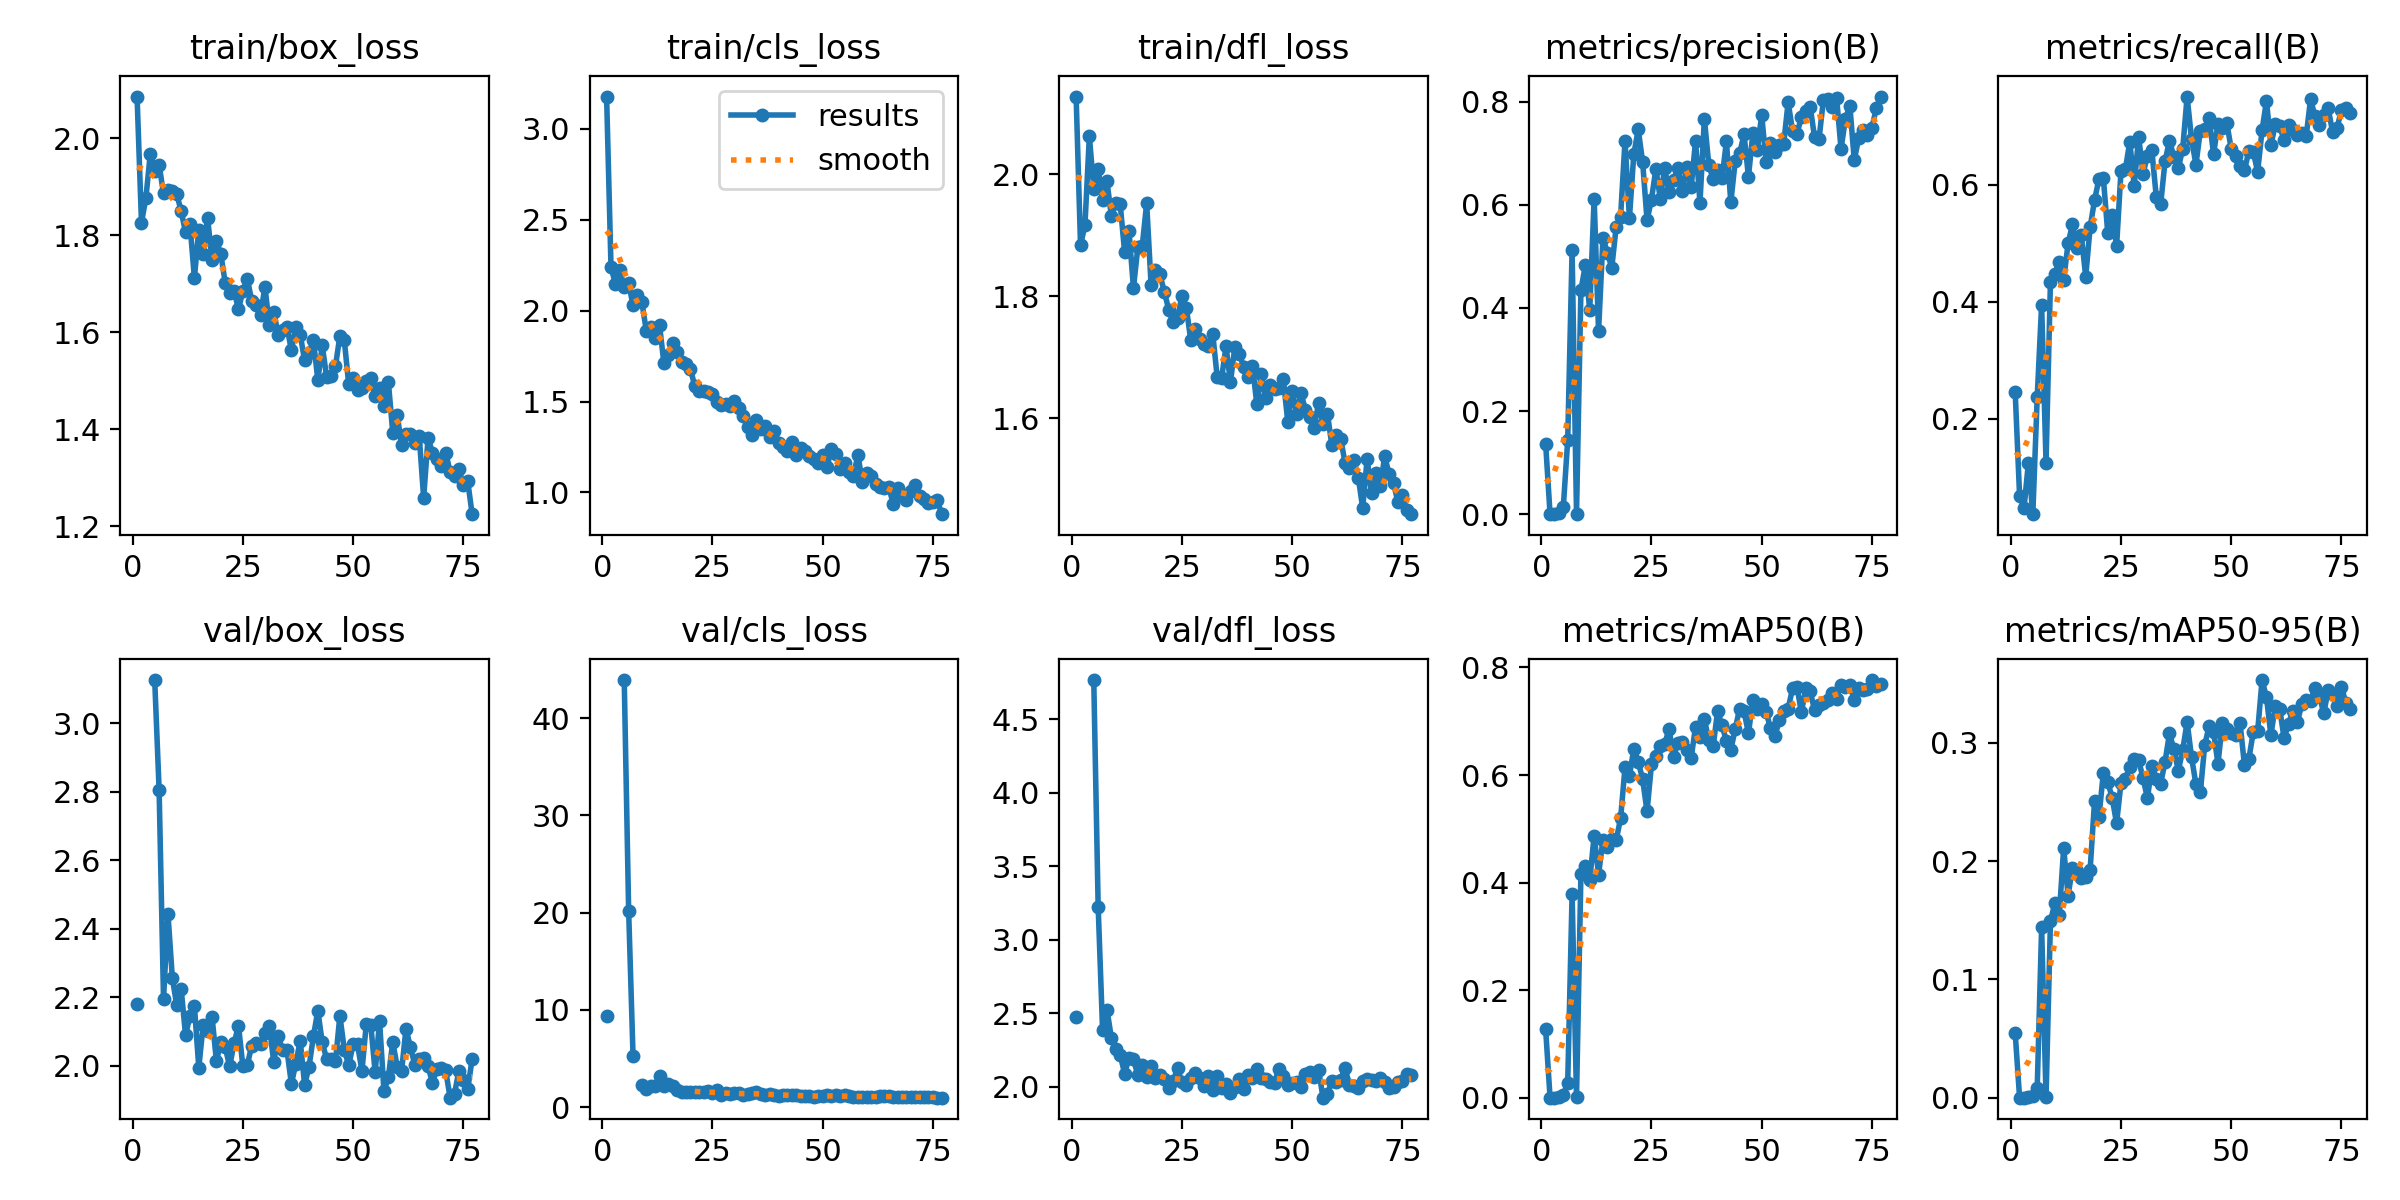

In [ ]:
# Display loss chart and metrics
from IPython.display import Image, display
import os

results_dir = f'{SAVE_DIR}/helmet_exp'

print('=== Training curves ===')
display(Image(filename=f'{results_dir}/results.png', width=900))

=== Confusion Matrix ===


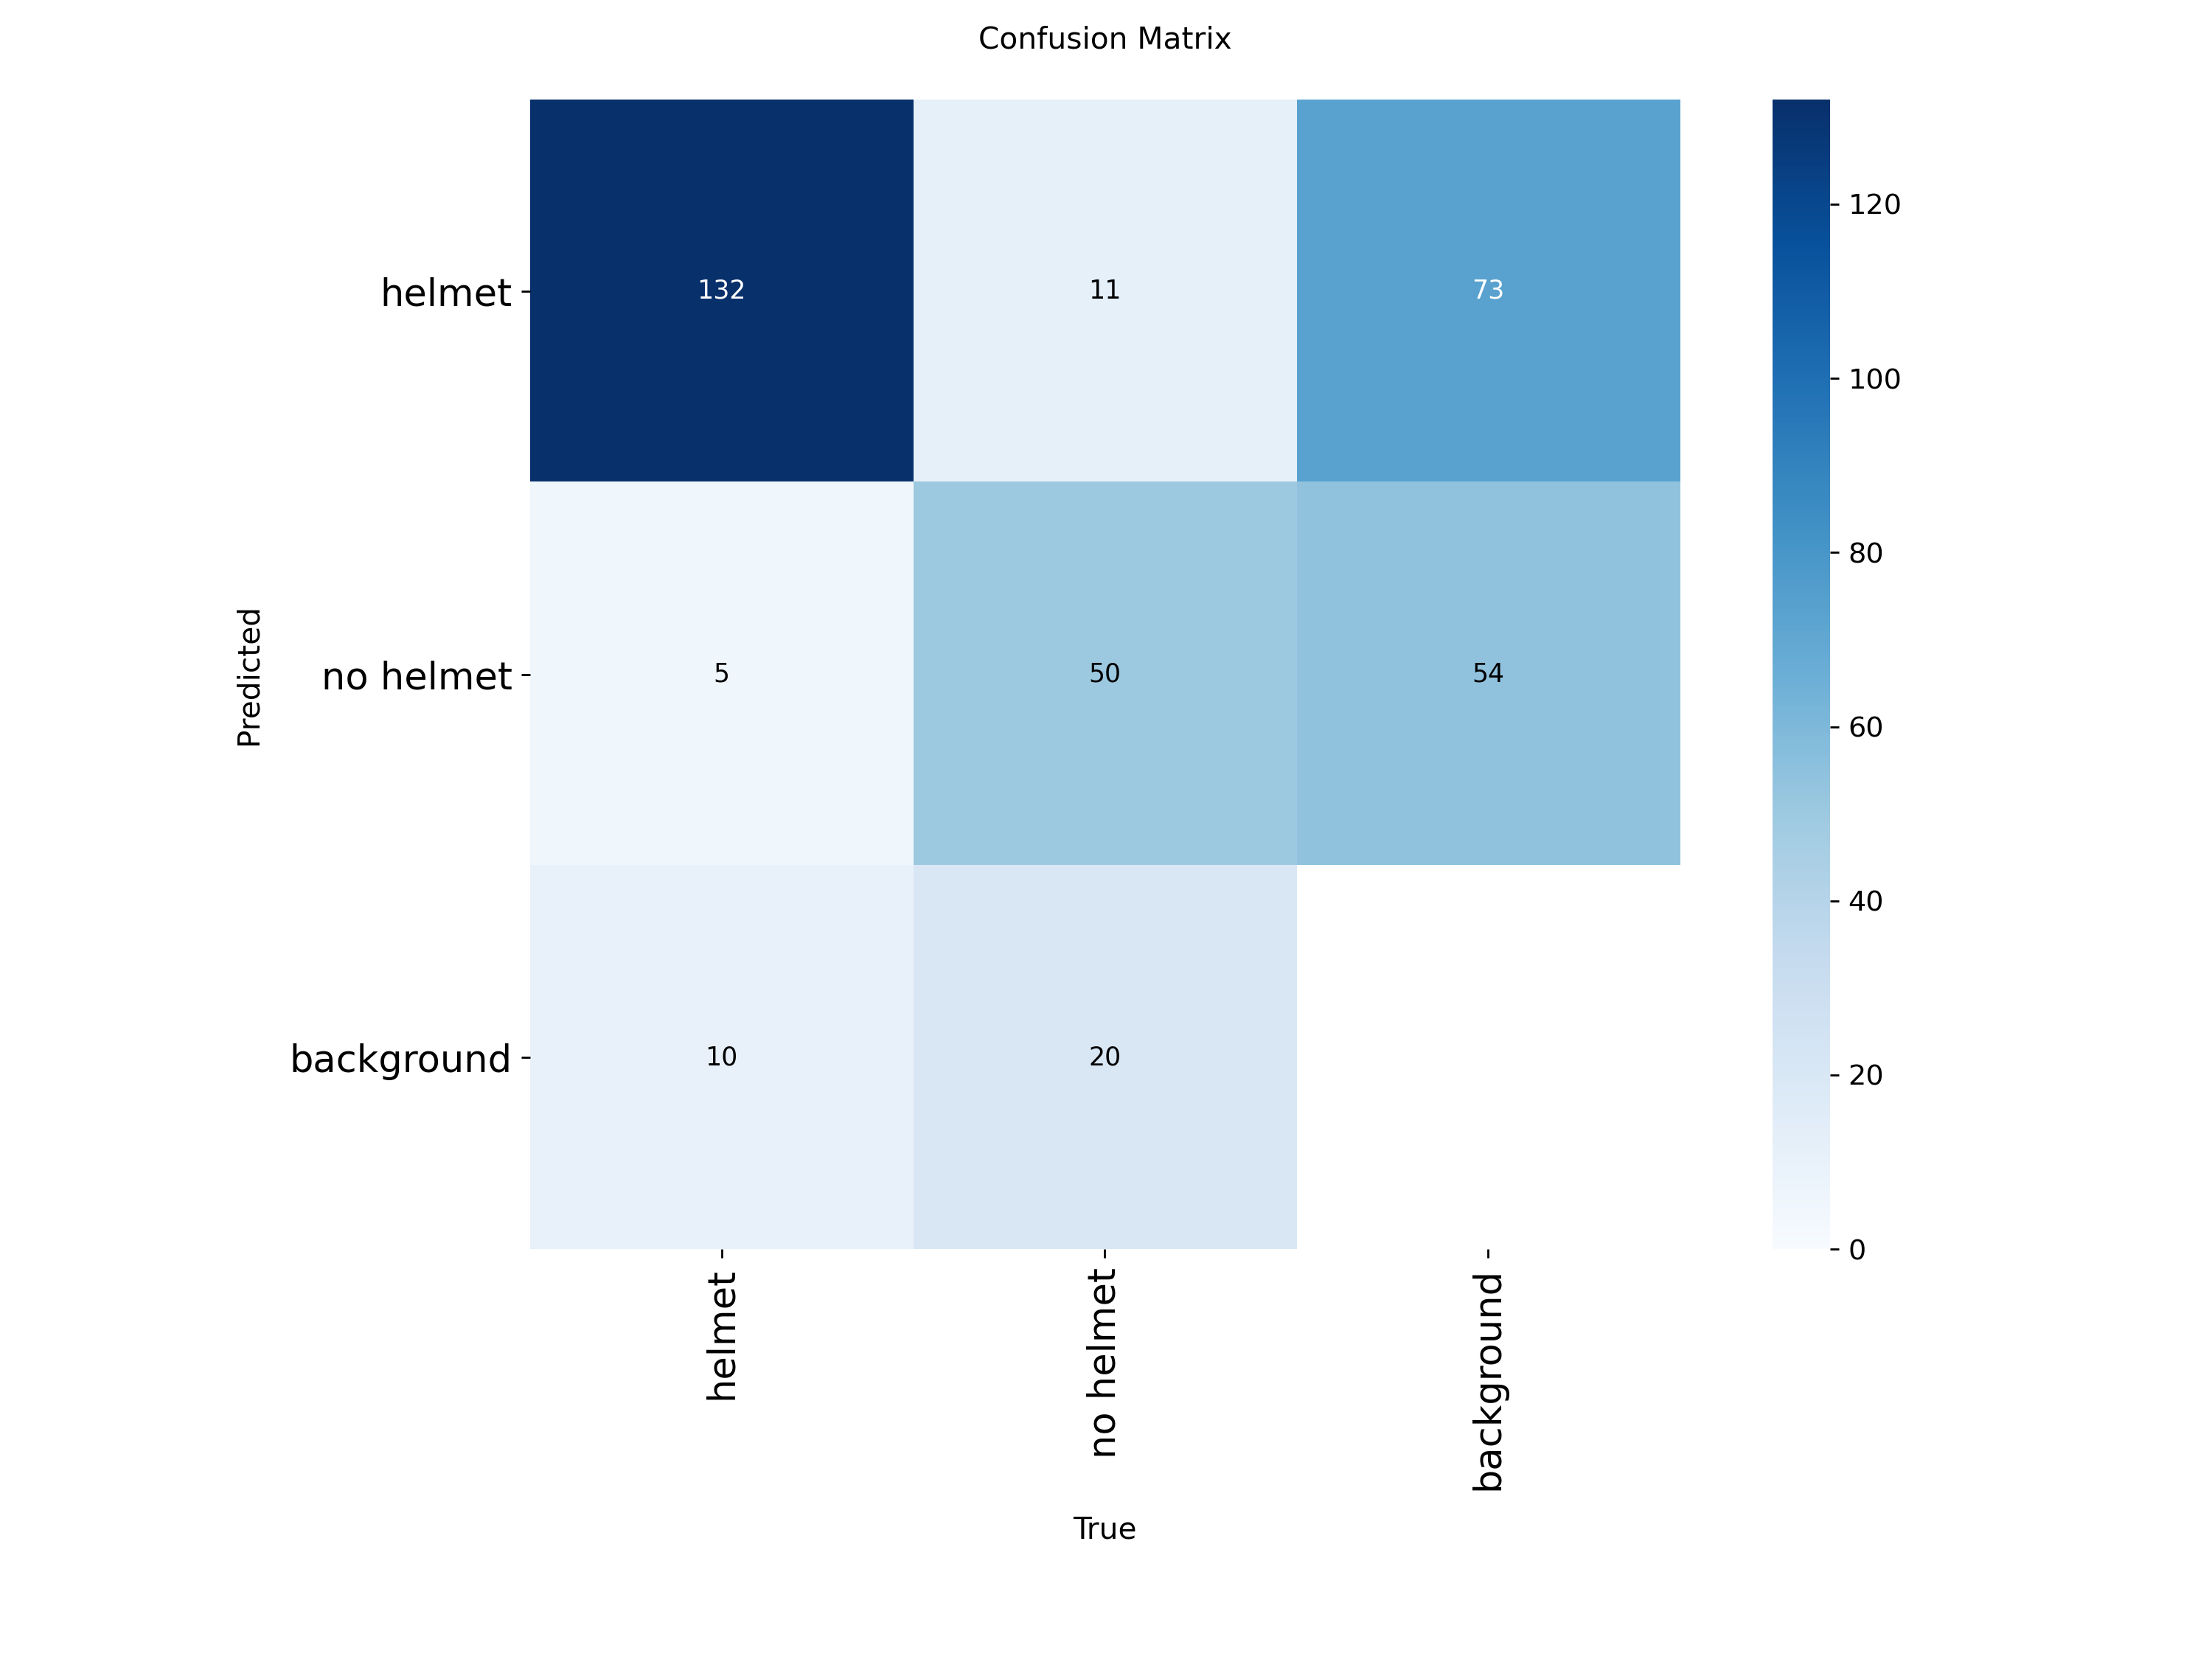

In [ ]:
print('=== Confusion Matrix ===')
display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))

In [ ]:
print('=== PR Curve ===')
display(Image(filename=f'{results_dir}/PR_curve.png', width=600))

=== PR Curve ===


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/helmet_detection/helmet_exp/PR_curve.png'

---
## Cell 7 — Evaluate metrics on the test set

In [ ]:
from ultralytics import YOLO

best_weights = f'{SAVE_DIR}/helmet_exp2/weights/best.pt'
model = YOLO(best_weights)

metrics = model.val(
    data=DATA_YAML,
    split='test',
    imgsz=640,
    device=0,
)

# ── Print results with evaluation ──────────────────────────────────────────────
precision = metrics.box.mp
recall    = metrics.box.mr
map50     = metrics.box.map50
map50_95  = metrics.box.map
f1        = 2 * precision * recall / max(precision + recall, 1e-9)

def grade(val, good, target):
    if val >= target: return '✅ Good'
    if val >= good:   return '🟡 Fine'
    return '❌ Needs improvement'

print('\n' + '='*48)
print('  EVALUATION RESULTS (test set)')
print('='*48)
print(f'  Precision   : {precision:.4f} ({precision*100:.1f}%)  {grade(precision, 0.80, 0.87)}')
print(f'  Recall      : {recall:.4f}    ({recall*100:.1f}%)  {grade(recall, 0.78, 0.85)}')
print(f'  F1-Score    : {f1:.4f}    ({f1*100:.1f}%)  {grade(f1, 0.80, 0.86)}')
print(f'  mAP@50      : {map50:.4f}    ({map50*100:.1f}%)  {grade(map50, 0.80, 0.87)}')
print(f'  mAP@50:95   : {map50_95:.4f} ({map50_95*100:.1f}%)  {grade(map50_95, 0.55, 0.65)}')
print('='*48)
print()
print('  Reference threshold:')
print('  🟡 Ổn     — sufficient for demo use')
print('  ✅ Tốt    — production-ready')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1451.8±217.5 MB/s, size: 81.0 KB)
val: Scanning /content/helmet_detection-1/test/labels.cache... 149 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 69.4Mit/s 0.0s
val: /content/helmet_detection-1/test/images/BikesHelmets446_png.rf.0cc2f4555c064f248176d467d2d5b667.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.7it/s 6.0s
                   all        149        273      0.905      0.845      0.922       0.59
           With Helmet        110        170      0.887      0.865       0.92      0.629
        Without Helmet         61        103      0.923      0.825      0.925      0.551
Speed: 3.4ms preprocess, 29.0ms inference, 0.1ms loss, 2.2ms postprocess per image

---
## Cell 8 — Run an inference test on a sample image.

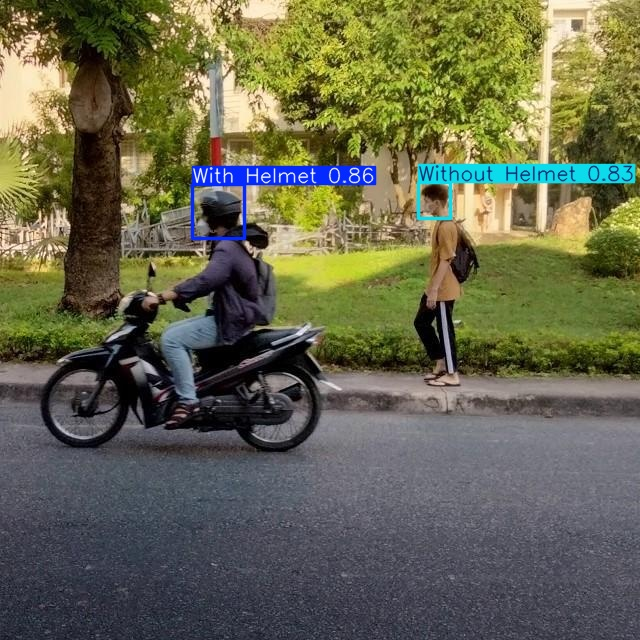

  Detected 2 objects in val22_jpg.rf.6a29a92f3ca7ad54c4bda8f0a712b21d.jpg



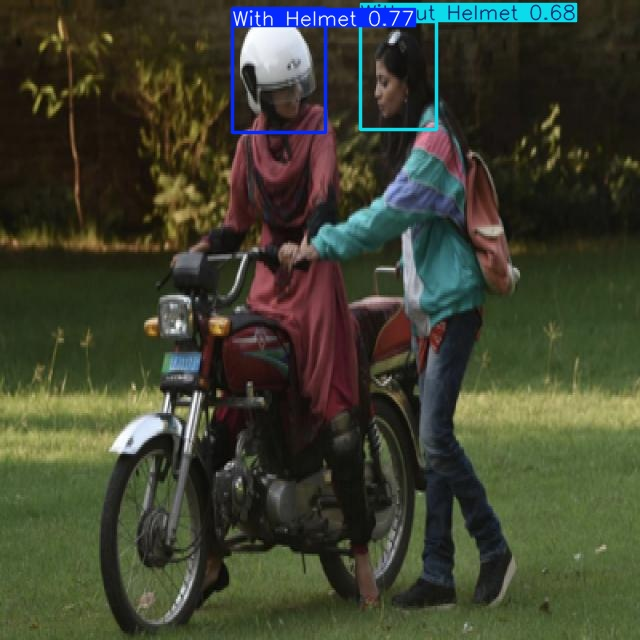

  Detected 2 objects in BikesHelmets113_png.rf.3a72b211980e5c4641ea74c0f030f793.jpg



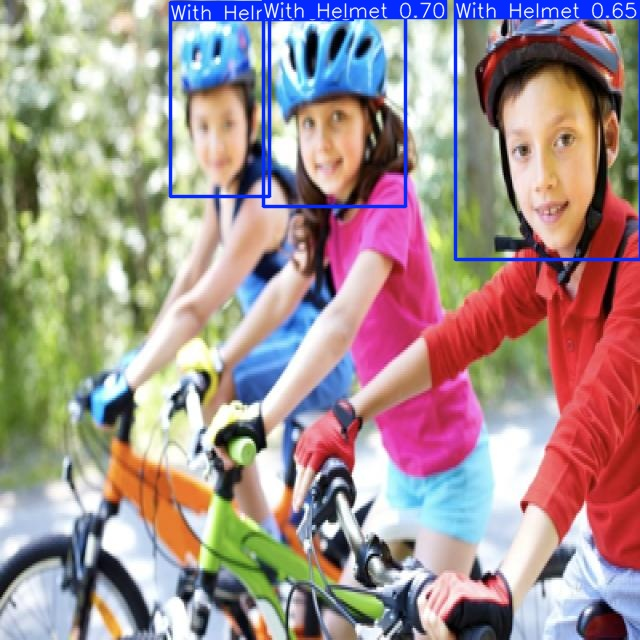

  Detected 3 objects in BikesHelmets360_png.rf.20e9c2f2037bd38230ca162e95371de7.jpg



In [ ]:
import glob
import random
from IPython.display import Image as IPImage, display
import cv2
from ultralytics import YOLO

model = YOLO(f'{SAVE_DIR}/helmet_exp2/weights/best.pt')

# Select 3 random images from the test set.
test_images = glob.glob(f'{dataset.location}/test/images/*.jpg')
samples = random.sample(test_images, min(3, len(test_images)))

for img_path in samples:
    results = model.predict(img_path, conf=0.45, imgsz=640, verbose=False)
    annotated = results[0].plot()  # bbox

    # Save and display
    out_path = '/tmp/sample_result.jpg'
    cv2.imwrite(out_path, annotated)
    display(IPImage(filename=out_path, width=700))

    # Print the detected quantity
    boxes = results[0].boxes
    print(f'  Detected {len(boxes)} objects in {img_path.split("/")[-1]}')
    print()

---
## Cell 9 — Speed ​​measurement inference

In [ ]:
import time
import glob
import random
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO(f'{SAVE_DIR}/helmet_exp2/weights/best.pt')

test_images = glob.glob(f'{dataset.location}/test/images/*.jpg')
samples = random.sample(test_images, min(20, len(test_images)))

# Warmup
dummy = np.zeros((640, 640, 3), dtype=np.uint8)
for _ in range(3):
    model.predict(dummy, verbose=False)

# Benchmark
times = []
for path in samples:
    frame = cv2.imread(path)
    t0 = time.perf_counter()
    model.predict(frame, conf=0.45, imgsz=640, verbose=False)
    times.append(time.perf_counter() - t0)

avg_ms  = np.mean(times) * 1000
avg_fps = 1.0 / np.mean(times)

print('='*40)
print('  INFERENCE SPEED (GPU T4)')
print('='*40)
print(f'  Avg latency : {avg_ms:.1f} ms/frame')
print(f'  Avg FPS     : {avg_fps:.1f}')
print('='*40)
if avg_fps >= 30:
    print('  ✅ Real-time (≥30 FPS)')
elif avg_fps >= 15:
    print('  🟡 Slow, but usable for video.')
else:
    print('  ❌ Too slow — try a smaller model (yolov8s/n)')

  INFERENCE SPEED (GPU T4)
  Avg latency : 27.7 ms/frame
  Avg FPS     : 36.0
  ✅ Real-time (≥30 FPS)


---
## Cell 10 — Download `best.pt` and save in ```weights/best.pt```



In [ ]:
from google.colab import files
import os

best_pt = f'{SAVE_DIR}/helmet_exp2/weights/best.pt'

if os.path.exists(best_pt):
    size_mb = os.path.getsize(best_pt) / 1e6
    print(f'📦 Downloading best.pt ({size_mb:.1f} MB)...')
    files.download(best_pt)
    print('✅ Download started!')
    print()

📦 Downloading best.pt (52.0 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!

Sau khi download xong:
  1. Copy best.pt vào thư mục weights/ trong project
  2. Sửa .env: MODEL_PATH=weights/best.pt
  3. Chạy: python scripts/run.py --source video.mp4


---
## Cell 11 — Export to ONNX for faster CPU deployment

ONNX runs `.pt` files on the CPU by approximately **1.5–2x**

In [ ]:
from ultralytics import YOLO
from google.colab import files

model = YOLO(f'{SAVE_DIR}/helmet_exp2/weights/best.pt')

# Export to ONNX
onnx_path = model.export(
    format='onnx',
    imgsz=640,
    simplify=True,   # optimize graph
    opset=17,
)

print(f'✅ Exported: {onnx_path}')
files.download(str(onnx_path))

print()
print('To use ONNX in your project, edit the .env file:')
print('  MODEL_PATH=weights/best.onnx')

---
## Cell 12 — (Optional) Resume training if Colab is interrupted

Run this cell instead of Cell 5 if the session is interrupted midway.

In [ ]:
from ultralytics import YOLO
import os

last_checkpoint = f'{SAVE_DIR}/helmet_exp2/weights/last.pt'

if not os.path.exists(last_checkpoint):
    print('❌ No checkpoint found. Please run Cell 5 from the beginning.')
else:
    print(f'▶️  Resuming from {last_checkpoint}...')
    model = YOLO(last_checkpoint)
    model.train(resume=True)   # Read the configuration again from the checkpoint
    print('✅ Training resumed and is complete!')